# MASTER THESIS - model V5 summer

This model is like the first model of summer but with new way to model occupancy

This notebook demonstrates the usage of the `DarkGreyBox` models via fitting them with `DarkGreyFit`

Model V3 --> this model is using the TiTmCn3R2C grey-box model on a summer period (1st of September to 15th of September) where there is no heating at all

## Importation

In [11]:
import sys
import importlib
from pathlib import Path

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiTmCn2R2C_summer_V5
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

Our temporal resolution is 5 minutes

In [12]:
# the duration of a record (in h - 5 minutes)
rec_duration = 5/60

## Data Loading and Preprocessing

The data is loaded from the CSV file 'data_summer' and processed to extract relevant variables for the thermal model.

In [13]:
input_df = pd.read_csv('./data/data_summer.csv', index_col=0, parse_dates=True)

input_df['Ti'] = input_df['R01_06_TRU01']
input_df['qv'] = input_df['R01_06_FCI01']
input_df['c'] = input_df['R01_06_CO201']  # Use processed CO2 column
input_df['Ta'] = input_df['HTR9_VES01_TUD01']
input_df['Ik'] = input_df['HTR9_VES01_SI01']
input_df['Tsup'] = input_df['HTRK_VEN01_SpTI01_C']


# Set initial conditions
input_df['Ti0'] = input_df['Ti'].iloc[0]
input_df['Tm0'] = input_df['Ti'].iloc[0]
input_df['c0'] = input_df['c'].iloc[0]
input_df['N0'] = 0 #We suppose no one in the room at the beginning


input_X = input_df[['qv', 'c', 'Ta', 'Ik', 'Tsup', 'Ti0', 'Tm0', 'c0', 'N0']]
input_y = input_df['Ti']


print(f'Input X shape: {input_X.shape}, input y shape: {input_y.shape}')

Input X shape: (4296, 9), input y shape: (4296,)


## Data Splitting

Initial conditions are set for the state variables at t=0, using the first measurements from the dataset. The data is then split into training (80%) and test (20%) sets for model validation.
`shuffle=False` to preserve the temporal order of the time series data. This is important for thermal modeling where historical context matters.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(input_X, input_y, test_size=0.2, shuffle=False)

print(f'Train: X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test: X shape: {X_test.shape}, y shape: {y_test.shape}')

Train: X shape: (3436, 9), y shape: (3436,)
Test: X shape: (860, 9), y shape: (860,)


## Model Training Parameters and Physical Constants

The parameter ranges are carefully chosen to reflect realistic physical bounds and to ensure the optimizer does not hit artificial limits during fitting. Capacitances and resistances are estimated from building material properties and geometry, while internal gains and constants are set according to typical values found in literature or building standards. This approach balances physical realism with flexibility for model calibration.


In [15]:
S_room = 11                             #Surface of the room, found on Revit (m²)
A_windows = 5.48                        #Window area found on Revit (m²)
H_room = 2.7                            #Height of the room (m)
V_room = S_room * H_room                #Volume of the room (m³)



# Capacitances initial guesses
# C=ρ×V×c_p [J/K] (ρ density kg/m³, V volume m³, c_p specific heat capacity J/kgK)
rho_air_init = 1.2          # kg/m³
cp_air_init = 1005          # J/kgK
rho_furn_init = 500         # kg/m³
cp_furn_init = 1200         # J/kgK
V_furn_init = 0.1 * V_room  # m³  (10% of room volume as furniture/contents volume)
Ci_i = rho_air_init * V_room * cp_air_init + rho_furn_init * V_furn_init * cp_furn_init

rho_wall = 2200             # kg/m³
cp_conc  = 840              # J/kgK
wall_thickness = 0.1        # m
Cm_i = rho_wall * (S_room * wall_thickness) * cp_conc  



# Resistances initial guesses
# R=1/(U*A) or 1/(h*A) [K/W]
h_conv = 8                     # W/m²K
S_int_mass = 0.6 * S_room      # internal surfaces area ~60%
Rim_i = 1 / (h_conv * S_int_mass)

U_env = 0.25                   # W/m²K
Rout_i= 1 / (U_env * S_room)


# Capacitances and resistances variation ranges
# WIDENED based on optimizer hitting bounds (see diagnostic cell)
Ci_min = 0.05*Ci_i      # Was 0.2x → lowered (optimizer wanted smaller)
Ci_max = 2*Ci_i         # Keep similar
Cm_min = 0.1*Cm_i       # Was 0.5x → lowered (optimizer wanted smaller)
Cm_max = 3*Cm_i         # Keep similar

Rim_min = 0.2*Rim_i     # Slightly lower
Rim_max = 2*Rim_i       # Keep similar
Rout_min = 0.1*Rout_i   # Was 0.5x → lowered (optimizer wanted more heat loss)
Rout_max = 2*Rout_i     # Keep similar



# Define training parameters
train_params_TiTmCn2R2C_summer_V5 = {
    'Ti0': {'value': input_df.iloc[0]['Ti0'], 'vary': False},               # Initial indoor temperature
    'Tm0': {'value': input_df.iloc[0]['Tm0'], 'vary': False},               # Initial thermal mass temperature
    'c0': {'value': input_df.iloc[0]['c0'], 'vary': False},                 # Initial CO2 concentration
    'N0': {'value': input_df.iloc[0]['N0'], 'vary': False},                 # Initial number of occupants
    
    #'Ci': {'value': Ci_i, 'vary': True, 'min': Ci_min, 'max': Ci_max},      # Air + light internal components heat capacity at air node (fast mass at Ti)
    #'Cm': {'value': Cm_i, 'vary': True, 'min': Cm_min, 'max': Cm_max},      # Thermal mass heat capacity (heavy structural mass at Tm)
    #'Rim': {'value': Rim_i, 'vary': True, 'min': Rim_min, 'max': Rim_max},  # Thermal resistance indoor air ↔ thermal mass (heat air ↔ building structure)
    #'Rout': {'value': Rout_i, 'vary': True, 'min': Rout_min, 'max': Rout_max},  # Overall thermal resistance indoor air ↔ ambient/outdoor air (heat loss path)
    'Ci': {'value': 5000, 'vary': True, 'min': 1000, 'max': 50000},
    'Cm': {'value': 100000, 'vary': True, 'min': 1000, 'max': 1000000},    # Bigger mass\n",
    'Rim': {'value': 0.005, 'vary': True, 'min': 0.001, 'max': 0.01},           # Mass-air  \n",
    'Rout': {'value': 0.15, 'vary': True, 'min': 0.01, 'max': 2.0},         # Envelope\n",
    'q_pers': {'value': 75, 'vary': False},                                 # Internal gains per person
    'q_equip_var': {'value': 80, 'vary': False},                            # Variable equipment gains per person
    'q_equip_const': {'value': 10, 'vary': False},                          # Constant equipment gains
    'V': {'value': S_room*H_room, 'vary': False},                           # Volume of the room
    'S': {'value': S_room, 'vary': False},                                  # Surface of the room
    'A': {'value': A_windows, 'vary': False},                               # Window area
    'G': {'value': 0.016, 'vary': False},                                   # Global radiation factor
    'c_out': {'value': 400, 'vary': False},                                 # Outdoor CO2 concentration
    'rho_air': {'value': 1.2, 'vary': False},                               # Air density
    'cp_air': {'value': 1000, 'vary': False},                               # Specific heat capacity of air
    'g': {'value': 0.55, 'vary': False},                                    # total solar energy transmittance of the glazing 
    'alpha': {'value': 0.1, 'vary': True, 'min': 0.01, 'max': 0.5},         # CO2 occupancy filter parameter
    'sigma_Ti': {'value': 0.1, 'vary': True, 'min': 0.01, 'max': 1.0},      # Ti measurement noise std
    'sigma_Tm': {'value': 0.05, 'vary': True, 'min': 0.01, 'max': 0.5},     # Tm measurement noise std
    'sigma_N': {'value': 0.5, 'vary': True, 'min': 0.1, 'max': 2.0},        # N measurement noise std
    'tau_N': {'value': 1800, 'vary': True, 'min': 600, 'max': 3600},        # Occupancy time constant (10-60 minutes)
    'N_max': {'value': 30, 'vary': False},                                  # Room capacity
}


# Verify stability
print(f"dt = {rec_duration:.4f} hours ({rec_duration * 60:.2f} minutes)")

dt = 0.0833 hours (5.00 minutes)


### 1: Initial conditions
Set up our initial conditions parameters map for testing

### 2: Error metric
To evaluate the performance of our models we will need to define an error metric. Again, there is a wide range of options available from `sklearn`

### 3: Fit method
Under the hood, `DarkGreyBox` uses `lmfit.minimize` to fit the thermal model parameters to the training data by passing it a custom objective function defined by the model class. The fit method used by `lmfit.minimize` can be customised as well. The standard Nelder-Mead and Levenberg-Marquardt methods work well in general. Here we use the Nelder-Mead method.

### 4: Choice of the model

In [16]:
ic_params_map = {
    'Ti0': lambda _X_test, y_test, _train_result: y_test.iloc[0],
    'Tm0': lambda X_test, _y_test, train_result: train_result.var['Tm'][-1] if 'Tm' in train_result.var else X_test.iloc[0]['Tm0'],
    'c0': lambda X_test, _y_test, train_result: train_result.var['c'][-1] if 'c' in train_result.var else X_test.iloc[0]['c0'],
    'N0': lambda X_test, _y_test, train_result: train_result.var['N'][-1] if 'N' in train_result.var else X_test.iloc[0]['N0'],
}

error_metric = rmse

method = 'nelder'

models = [TiTmCn2R2C_summer_V5(train_params_TiTmCn2R2C_summer_V5, rec_duration)]

Now, it is time to run the simulation:

In [17]:
# Run the darkgreyfit
df = darkgreyfit(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ic_params_map=ic_params_map,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    method=method,
    n_jobs=1
)

print("Fitting complete!")
print(f"DataFrame shape: {df.shape}")

df

model = df.iloc[0][('train', 'model')]
train_results = df.iloc[0][('train', 'model_result')]
test_results = df.iloc[0][('test', 'model_result')]

# Display model parameters safely
if hasattr(model, "result") and hasattr(model.result, "params"):
    display(model.result.params)
else:
    print("Model parameters not available.")

# Print initial, real initial guess (used in fit), and estimated R and C values
# Initial parameter guesses (from physical calculations)
try:
    init_params = {
        'Ci': {'value': Ci_i},
        'Cm': {'value': Cm_i},
        'Rim': {'value': Rim_i},
        'Rout': {'value': Rout_i}
    }
except NameError:
    # If any of the variables are not defined, set to None
    init_params = {
        'Ci': {'value': None},
        'Cm': {'value': None},
        'Rim': {'value': None},
        'Rout': {'value': None}
    }

# Real initial guess used in fit (from train_params_TiTmCn2R2C_summer)
real_init_params = {}
for key in ['Ci', 'Cm', 'Rim', 'Rout']:
    try:
        real_init_params[key] = train_params_TiTmCn2R2C_summer[key]['value']
    except Exception:
        real_init_params[key] = None

if hasattr(model, "result") and hasattr(model.result, "params"):
    est_params = model.result.params
    print("Parameter   | Initial Guess (calc) | Real Initial Guess (used) | Estimated Value")
    print("--------------------------------------------------------------------------")
    for key in ['Ci', 'Cm', 'Rim', 'Rout']:
        init_val = init_params[key]['value']
        real_init_val = real_init_params[key]
        est_val = est_params[key].value if key in est_params else None
        if init_val is not None and real_init_val is not None and est_val is not None:
            print(f"{key:10} | {init_val:18.4f} | {real_init_val:23.4f} | {est_val:15.4f}")
        elif init_val is not None and real_init_val is not None:
            print(f"{key:10} | {init_val:18.4f} | {real_init_val:23.4f} | {'N/A':>15}")
        elif real_init_val is not None and est_val is not None:
            print(f"{key:10} | {'N/A':>18} | {real_init_val:23.4f} | {est_val:15.4f}")
        elif init_val is not None and est_val is not None:
            print(f"{key:10} | {init_val:18.4f} | {'N/A':>23} | {est_val:15.4f}")
        else:
            print(f"{key:10} | {'N/A':>18} | {'N/A':>23} | {'N/A':>15}")
else:
    print("Model parameters not available for comparison.")

2026-01-26 18:38:20,342 darkgreybox  INFO     Training models...


KeyError: 'sigma_obs_Ti'

## Train results

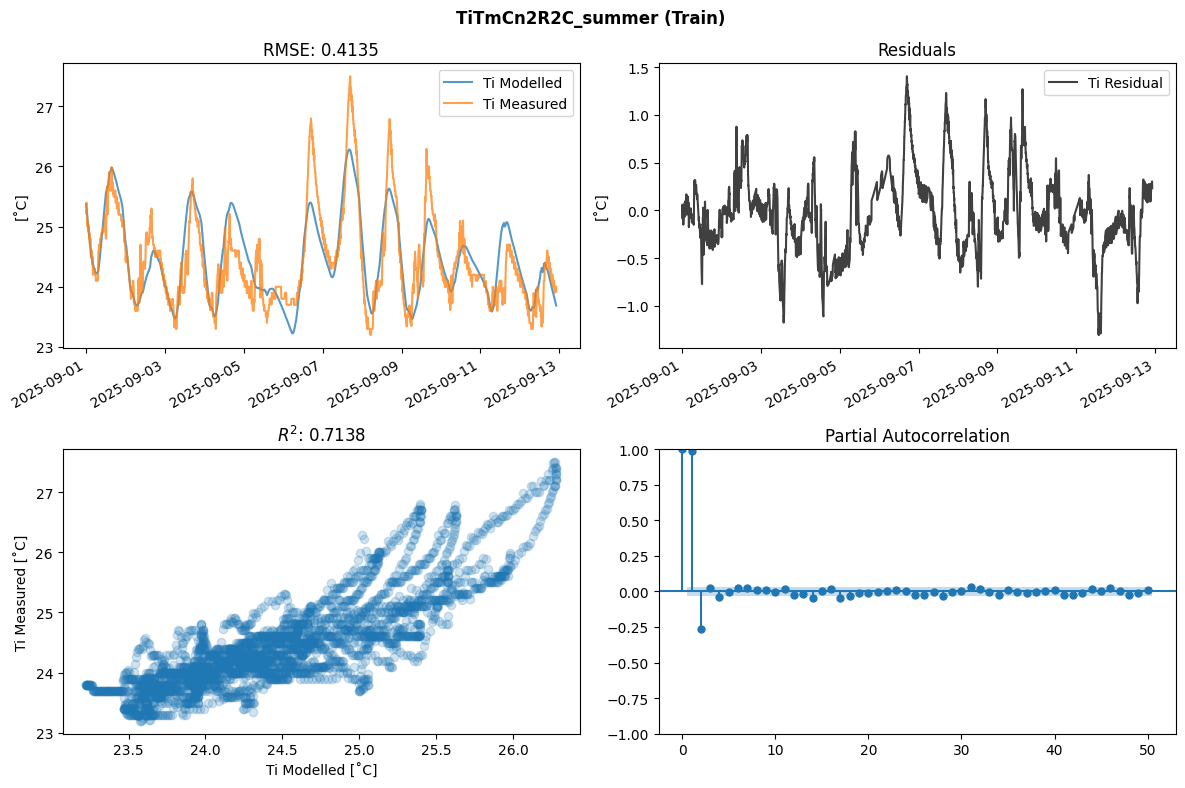

In [ ]:
plot(y_train, train_results, 'TiTmCn2R2C_summer (Train)')

## Test results

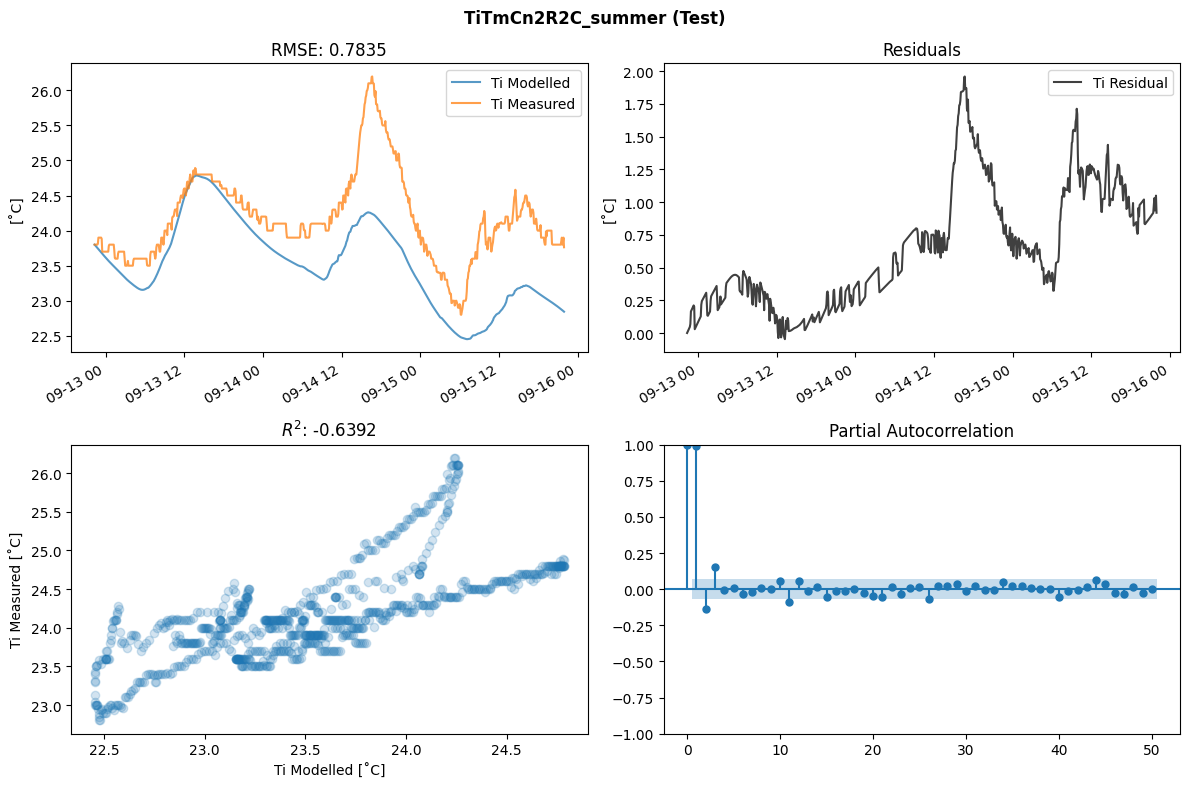

In [ ]:
plot(y_test, test_results, 'TiTmCn2R2C_summer (Test)')

## Plot the different heat gains

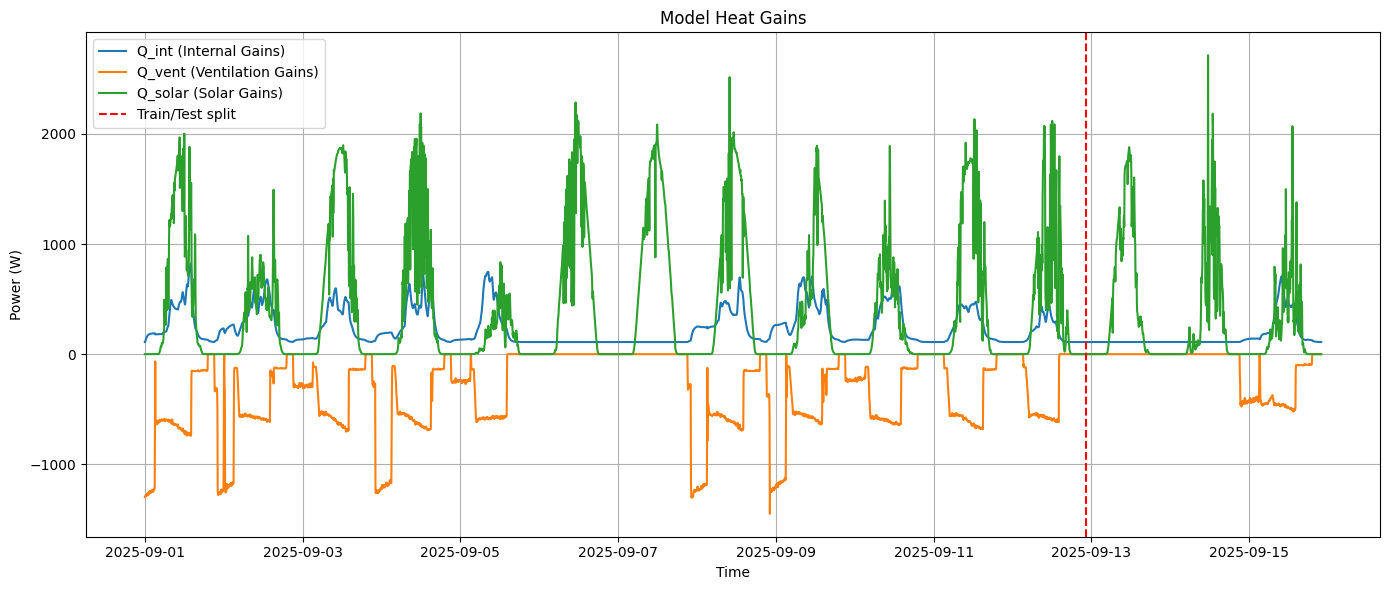

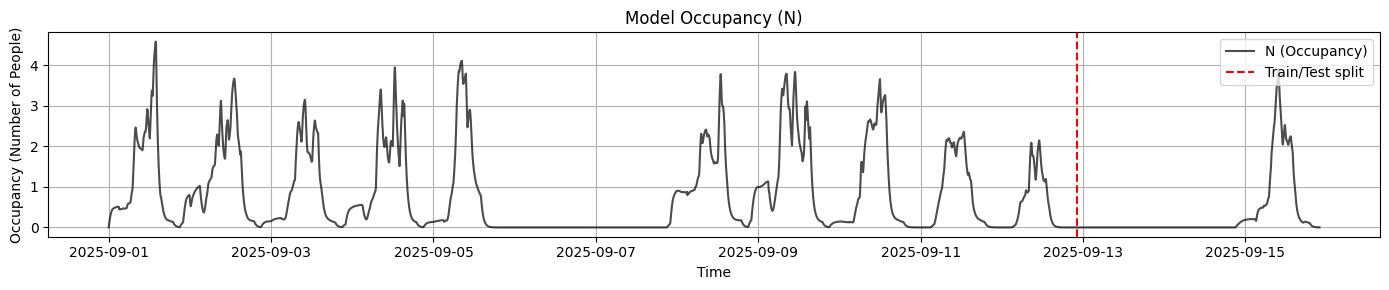

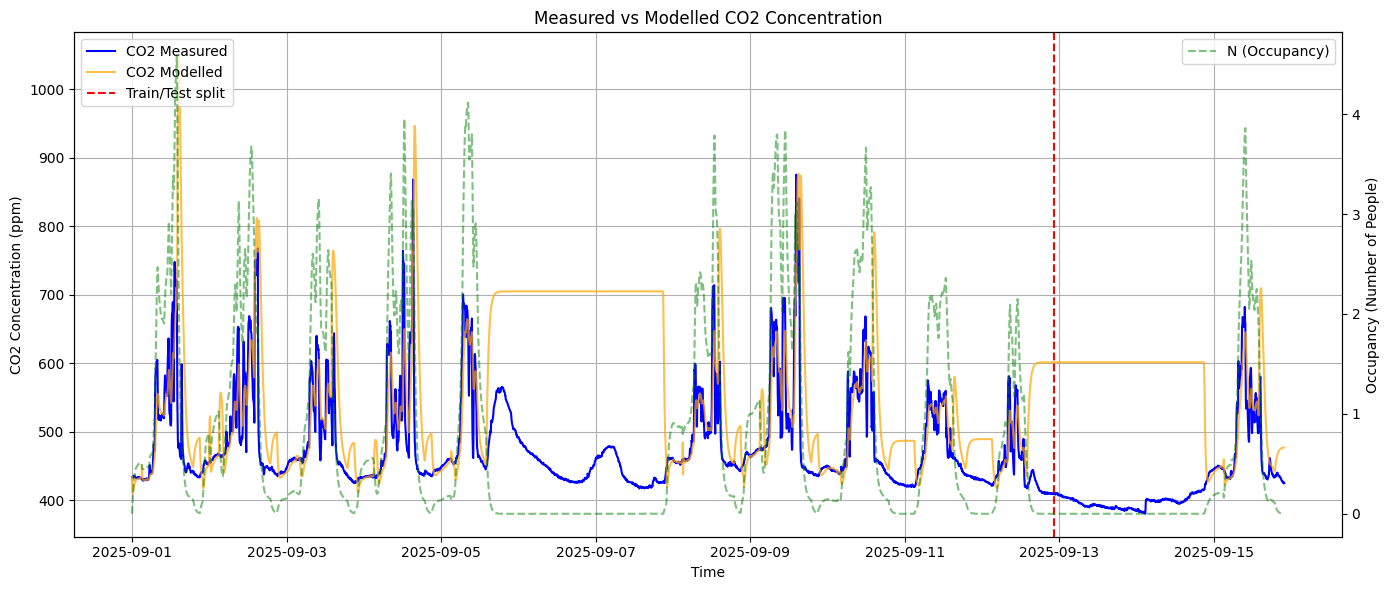

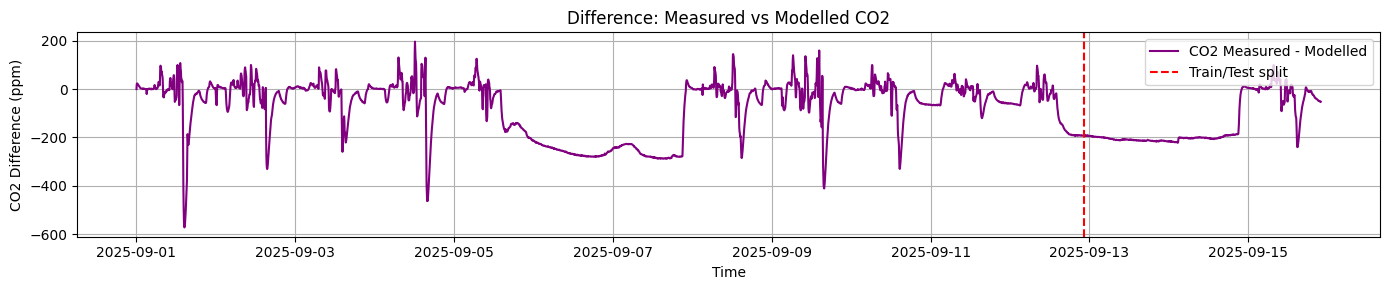

In [ ]:
# Helper function to safely extract variables from results
def get_var(result, key, default=0):
    return result.var[key] if key in result.var else np.zeros(len(result.var[list(result.var.keys())[0]]))

# Extract Q_int, Q_vent, Q_solar, and N from train and test results
Q_int_train = get_var(train_results, 'Q_int')
Q_vent_train = get_var(train_results, 'Q_vent')
Q_solar_train = get_var(train_results, 'Q_solar')
N_train = get_var(train_results, 'N')

Q_int_test = get_var(test_results, 'Q_int')
Q_vent_test = get_var(test_results, 'Q_vent')
Q_solar_test = get_var(test_results, 'Q_solar')
N_test = get_var(test_results, 'N')

# Concatenate train and test for full time series
Q_int_full = np.concatenate([Q_int_train, Q_int_test])
Q_vent_full = np.concatenate([Q_vent_train, Q_vent_test])
Q_solar_full = np.concatenate([Q_solar_train, Q_solar_test])
N_full = np.concatenate([N_train, N_test])

# Get full index from y_train and y_test
full_index = pd.Index(list(y_train.index) + list(y_test.index))

# Plot heat gains
fig1, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(full_index, Q_int_full, label='Q_int (Internal Gains)')
ax1.plot(full_index, Q_vent_full, label='Q_vent (Ventilation Gains)')
ax1.plot(full_index, Q_solar_full, label='Q_solar (Solar Gains)')
ax1.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax1.set_xlabel('Time')
ax1.set_ylabel('Power (W)')
ax1.set_title('Model Heat Gains')
ax1.legend(loc='upper left')
ax1.grid(True)
plt.tight_layout()
plt.show()

# Plot N (occupancy) separately
fig2, ax2 = plt.subplots(figsize=(14, 3))
ax2.plot(full_index, N_full, color='black', label='N (Occupancy)', linewidth=1.5, alpha=0.7)
ax2.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax2.set_xlabel('Time')
ax2.set_ylabel('Occupancy (Number of People)')
ax2.set_title('Model Occupancy (N)')
ax2.legend(loc='upper right')
ax2.grid(True)
plt.tight_layout()
plt.show()


# Plot the difference between measured CO2 (c) and modelled CO2, along with N
# Extract measured and modelled CO2 concentrations
c_measured = pd.concat([input_df.loc[y_train.index, 'c'], input_df.loc[y_test.index, 'c']])
c_modelled = np.concatenate([get_var(train_results, 'c'), get_var(test_results, 'c')])

# Plot measured vs modelled CO2 and N
fig3, ax3 = plt.subplots(figsize=(14, 6))
ax3.plot(full_index, c_measured, label='CO2 Measured', color='blue')
ax3.plot(full_index, c_modelled, label='CO2 Modelled', color='orange', alpha=0.7)
ax3.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax3.set_xlabel('Time')
ax3.set_ylabel('CO2 Concentration (ppm)')
ax3.set_title('Measured vs Modelled CO2 Concentration')
ax3.legend(loc='upper left')
ax3.grid(True)

# Add a secondary axis for N
ax4 = ax3.twinx()
ax4.plot(full_index, N_full, label='N (Occupancy)', color='green', linestyle='--', alpha=0.5)
ax4.set_ylabel('Occupancy (Number of People)')
ax4.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Plot the difference between measured and modelled CO2
fig4, ax5 = plt.subplots(figsize=(14, 3))
co2_diff = c_measured.values - c_modelled
ax5.plot(full_index, co2_diff, label='CO2 Measured - Modelled', color='purple')
ax5.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax5.set_xlabel('Time')
ax5.set_ylabel('CO2 Difference (ppm)')
ax5.set_title('Difference: Measured vs Modelled CO2')
ax5.legend(loc='upper right')
ax5.grid(True)
plt.tight_layout()
plt.show()